In [38]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import to_categorical

In [39]:
nb_classes = 10 #On doit reconnaitre 10 chiffres différents

In [40]:
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
print ('Apprentissage : ', training_images.shape[0])
print ('Test : ', test_images.shape[0])

Apprentissage :  60000
Test :  10000


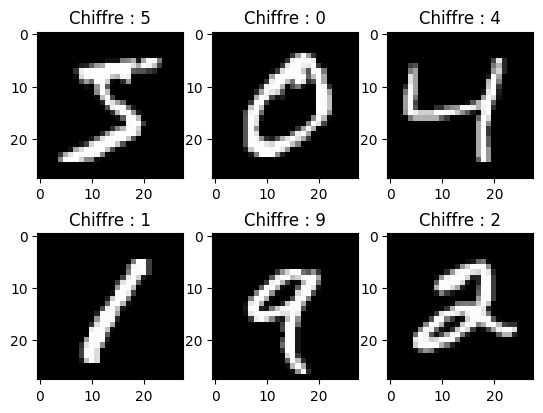

In [41]:
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(training_images[i], cmap='gray', interpolation='none')
    plt.title("Chiffre : {}".format(training_labels[i]))

# Reshape les images en tableaux 28x28

In [42]:
training_images = training_images.reshape(60000, 784)
test_images = test_images.reshape(10000, 784)
training_images = training_images.astype('float32')
test_images = test_images.astype('float32')
training_images /= 255
test_images /= 255

training_labels_categories = to_categorical(training_labels, nb_classes)
test_labels_categories = to_categorical(test_labels, nb_classes)

"J’ai décidé de créer un réseau qui prend nos entrées, utilise une première couche de 500 neurones et qui ensuite envoie cela dans une couche finale de 10 neurones qui contiendront la probabilité que nos chiffres soit un 1, un 2, etc."

In [45]:
model = Sequential()
model.add(Dense(500, input_shape=(784,)))
model.add(Activation('relu'))
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy', optimizer=SGD(0.5), metrics=['accuracy'])

history = model.fit(training_images, training_labels_categories, batch_size=500, epochs=10,
                    verbose=2, validation_data=(test_images, test_labels_categories))
score = model.evaluate(test_images, test_labels_categories, verbose=0)
print('Score sur le dataset de test:', score[1]*100, "%")

Epoch 1/10
120/120 - 1s - 6ms/step - accuracy: 0.8668 - loss: 0.4513 - val_accuracy: 0.9344 - val_loss: 0.2387
Epoch 2/10
120/120 - 0s - 4ms/step - accuracy: 0.9402 - loss: 0.2122 - val_accuracy: 0.9506 - val_loss: 0.1733
Epoch 3/10
120/120 - 0s - 4ms/step - accuracy: 0.9549 - loss: 0.1622 - val_accuracy: 0.9591 - val_loss: 0.1428
Epoch 4/10
120/120 - 0s - 4ms/step - accuracy: 0.9626 - loss: 0.1325 - val_accuracy: 0.9644 - val_loss: 0.1242
Epoch 5/10
120/120 - 0s - 4ms/step - accuracy: 0.9687 - loss: 0.1132 - val_accuracy: 0.9674 - val_loss: 0.1109
Epoch 6/10
120/120 - 0s - 4ms/step - accuracy: 0.9725 - loss: 0.0990 - val_accuracy: 0.9693 - val_loss: 0.1012
Epoch 7/10
120/120 - 0s - 4ms/step - accuracy: 0.9755 - loss: 0.0872 - val_accuracy: 0.9705 - val_loss: 0.0963
Epoch 8/10
120/120 - 0s - 4ms/step - accuracy: 0.9782 - loss: 0.0779 - val_accuracy: 0.9749 - val_loss: 0.0872
Epoch 9/10
120/120 - 0s - 4ms/step - accuracy: 0.9810 - loss: 0.0700 - val_accuracy: 0.9730 - val_loss: 0.0858
E

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step


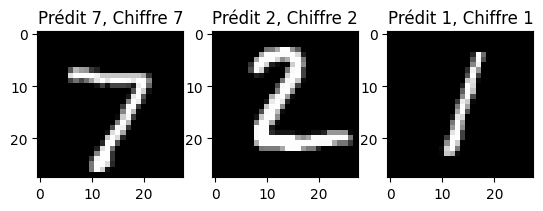

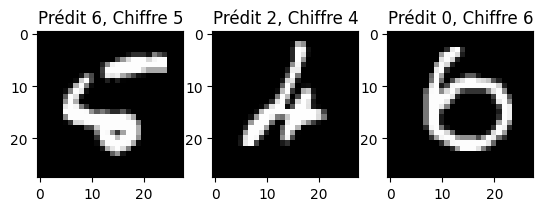

In [46]:
predictions = model.predict(test_images)
classes_predites = np.argmax(predictions, axis=1)

correct_indices = np.nonzero(classes_predites == test_labels)[0]
incorrect_indices = np.nonzero(classes_predites != test_labels)[0]

plt.figure()
for i, correct in enumerate(correct_indices[:3]):
    plt.subplot(1, 3, i+1)
    plt.imshow(test_images[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Prédit {}, Chiffre {}".format(classes_predites[correct], test_labels[correct]))

plt.figure()
for i, incorrect in enumerate(incorrect_indices[:3]):
    plt.subplot(1, 3, i+1)
    plt.imshow(test_images[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Prédit {}, Chiffre {}".format(classes_predites[incorrect], test_labels[incorrect]))